# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 23     |  |
| :-------------|:-------------|
| Joppe van Duin | 6405835 |
| Antony Rezende Bruinsma| 6039960 |

In [30]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

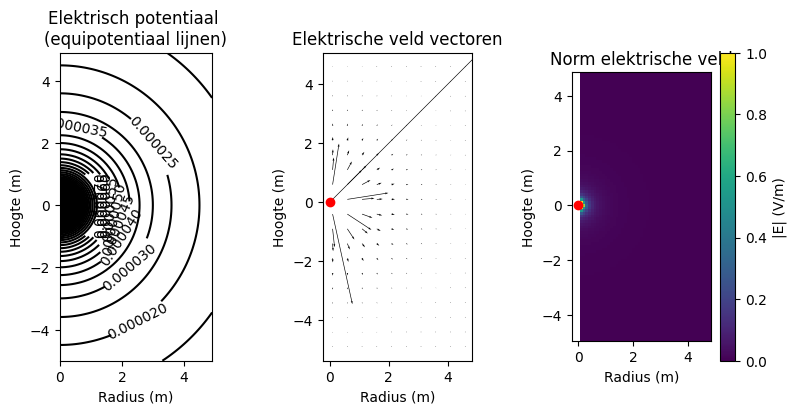

In [31]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

Index voor z = 0 m: 50


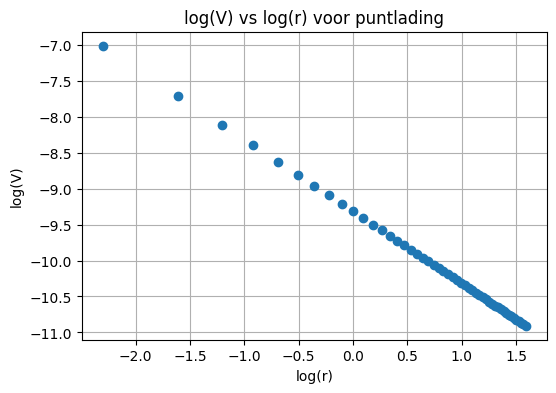

Exponent (helling) van de fit: -1.0000
Intercept van de fit: -9.3171


In [32]:
###
###Hier jouw code###

# 1. Bepaal index die hoort bij z = 0 m
z0_index_P = np.argmin(np.abs(z - 0))
print(f"Index voor z = 0 m: {z0_index_P}")

# 2. Plot log(V) tegen log(r)
V_z0 = V[z0_index_P, :]
# Straal is gewoon r (afstand tot oorsprong in dit 1D profiel)
r_vals = r

# Verwijder het punt r=0 om log-problemen te vermijden
mask = r_vals > 0
r_nonzero = r_vals[mask]
V_nonzero = V_z0[mask]


plt.figure(figsize=(6,4))
plt.plot(np.log(r_nonzero), np.log(V_nonzero), 'o')
plt.xlabel("log(r)")
plt.ylabel("log(V)")
plt.title("log(V) vs log(r) voor puntlading")
plt.grid(True)
plt.show()

# 3. Fit log(V) = a * log(r) + b
coeffs = np.polyfit(np.log(r_nonzero), np.log(V_nonzero), 1)
slope, intercept = coeffs
# 4 . Print de exponent (helling) en intercept van de fit
print(f"Exponent (helling) van de fit: {slope:.4f}")
print(f"Intercept van de fit: {intercept:.4f}")


##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

Index voor z = 0 m (veld): 50


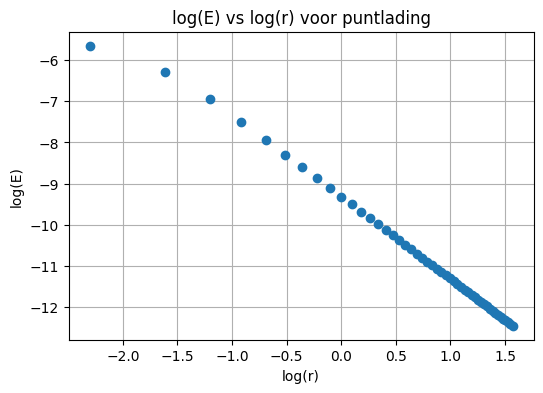

Exponent (helling) van de fit voor E: -1.9111
y-intersect van de fit voor E: -9.3979


In [33]:
###

# 1. Index voor z = 0 (deze heb je al, maar we hergebruiken hem)
z0_index = np.argmin(np.abs(z - 0))
print(f"Index voor z = 0 m (veld): {z0_index}")

# 2. Plot log(E) tegen log(r)
# We gebruiken de norm van het veld
E_z0 = normE[z0_index, :]

# Straal hoort bij r_for_E
r_vals_E = r_for_E

# Verwijder r = 0 om log-problemen te vermijden
maskE = r_vals_E > 0
r_nonzero_E = r_vals_E[maskE]
E_nonzero = E_z0[maskE]

plt.figure(figsize=(6,4))
plt.plot(np.log(r_nonzero_E), np.log(E_nonzero), 'o')
plt.xlabel("log(r)")
plt.ylabel("log(E)")
plt.title("log(E) vs log(r) voor puntlading")
plt.grid(True)
plt.show()

# 3. Fit log(E) = a * log(r) + b
coeffs_E = np.polyfit(np.log(r_nonzero_E), np.log(E_nonzero), 1)
slope_E, y_intersect_E = coeffs_E

# 4. Print de exponent (helling) en intercept van de fit
print(f"Exponent (helling) van de fit voor E: {slope_E:.4f}")
print(f"y-intersect van de fit voor E: {y_intersect_E:.4f}")
###

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [34]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

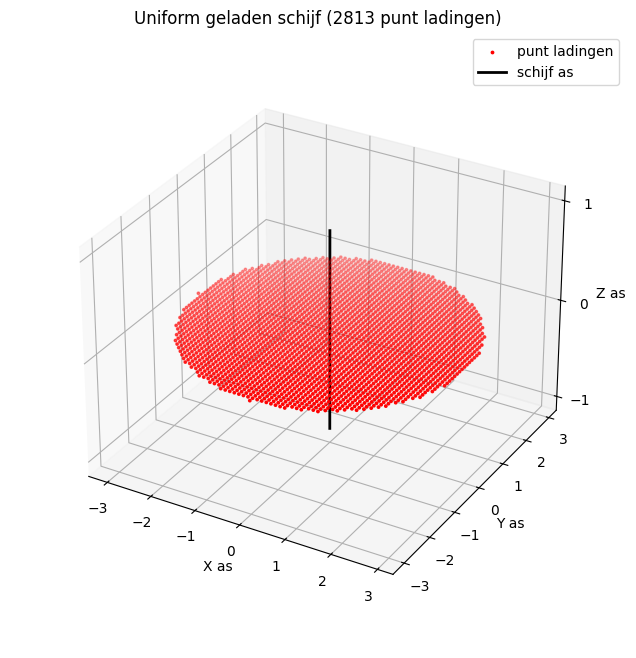

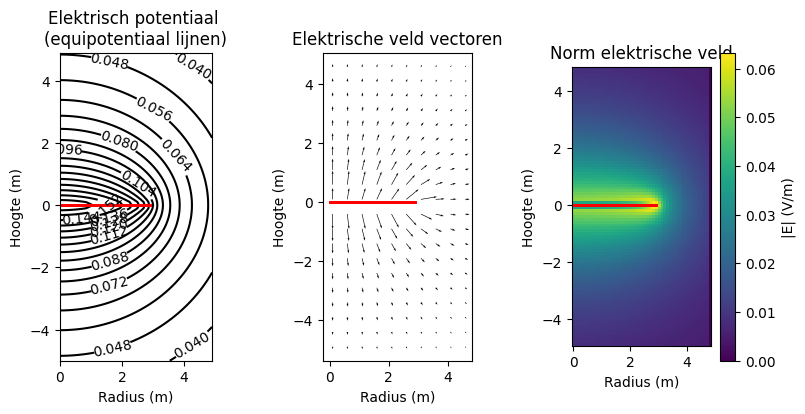

In [35]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk radius is de straal van de geladen schijf die wordt gevormd. Als deze naar 0 gaat, dan zal het geen schijf meer zijn maar een enkele puntlading. Grote straal betekent ook meer lading en sterker veld.
2. De gridstep is de afstand tussen de puntladingen binnen de geladen schijf. Als de gridstep groot is, zullen de puntladingen ver uit elkaar liggen. Als de gridstep klein is, zullen ze dichtbij elkaar liggen. Dit beinvloedt het aantal punten in de simulatie en verandert de snelheid van de code. Als ik de gridstep laat staan op 0.1 m, dan duurt de run van de code 0.9 s. Stel ik zet deze op 0.05m dan duurt het al 2.4 s, omdat er veel meer punten moeten worden geladen. Kleinere gridstep is accurater, maar langzamer voor gebruik.
3. Z-coord-disk verschuift de schijf over de z-as, dit verandert verder niks op de simulatie, behalve dan dat diie verder omhoog of omlaag zit. Op de plot zelf zie je niet eens verschil als je dit plot.


#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [36]:
###
# Totale lading op de schijf
#Q_tot = N*q
Q_total = number_point_charges_on_disk * charge_one_point

# Oppervlakte van de schijf
#A = pi * r^2
A_disk = np.pi * disk_radius**2

# Ladingsdichtheid sigma
#sigma = Q/A
sigma = Q_total / A_disk

print(f"Ladingsdichtheid σ = {sigma:.3e} C/m^2")
###

Ladingsdichtheid σ = 9.949e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

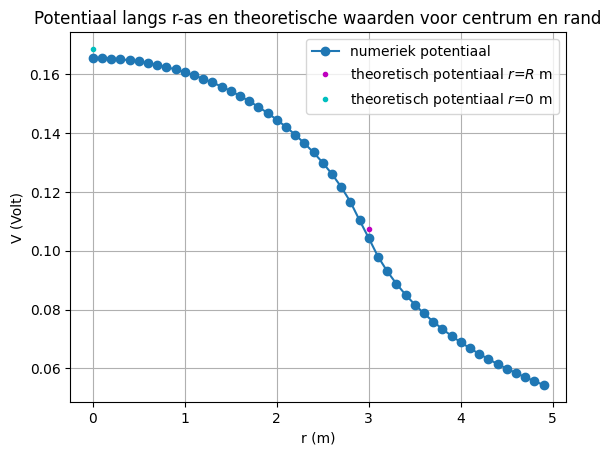

In [37]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = np.where(abs(z) < 1e-10)[0][0]

V_0 = V[idx_z_zero, 0]  # potentiaal op r = 0
idx_r_R = np.argmin(abs(r - disk_radius))
V_R = V[idx_z_zero, idx_r_R]  # potentiaal op de straal van de schijf
r_R = r[idx_r_R]  # straal van de schijf
V_center_theory = sigma * disk_radius / (2 * epsilon0)
V_edge_theory   = sigma * disk_radius / (np.pi * epsilon0)

plt.title("Potentiaal langs r-as en theoretische waarden voor centrum en rand")
plt.plot(r, V[idx_z_zero, :], "o-", label="numeriek potentiaal")
plt.plot(r_R, V_edge_theory, "m.", label="theoretisch potentiaal $r$=$R$ m")
plt.plot(0, V_center_theory, "c.", label="theoretisch potentiaal $r$=0 m")
plt.legend()
plt.xlabel("r (m)")
plt.ylabel("V (Volt)")
plt.grid(True)
plt.show()

#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


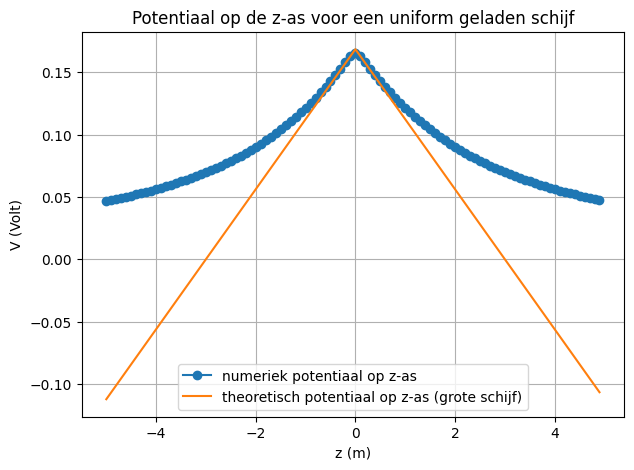

In [38]:
###
# 1. Numeriek potentiaal op de z-as (r = 0)
idx_r_zero = np.where(abs(r) < 1e-10)[0][0]     # index waar r = 0
V_z_numeric = V[:, idx_r_zero]                  # potentiaal langs de z-as

# 2. Theoretisch potentiaal op de z-as voor een grote schijf (Griffiths 2.26)
#    V(z) = σ/(2ε0) * (R - |z|)
V_z_theory = (sigma / (2 * epsilon0)) * (disk_radius - np.abs(z))

# 3. Plotten en opslaan
plt.figure(figsize=(7,5))
plt.plot(z, V_z_numeric, "o-", label="numeriek potentiaal op z-as")
plt.plot(z, V_z_theory, "-", label="theoretisch potentiaal op z-as (grote schijf)")

plt.title("Potentiaal op de z-as voor een uniform geladen schijf")
plt.xlabel("z (m)")
plt.ylabel("V (Volt)")
plt.legend()
plt.grid(True)

#plt.savefig("potentiaal_z_as.png", dpi=300)
plt.show()
###

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

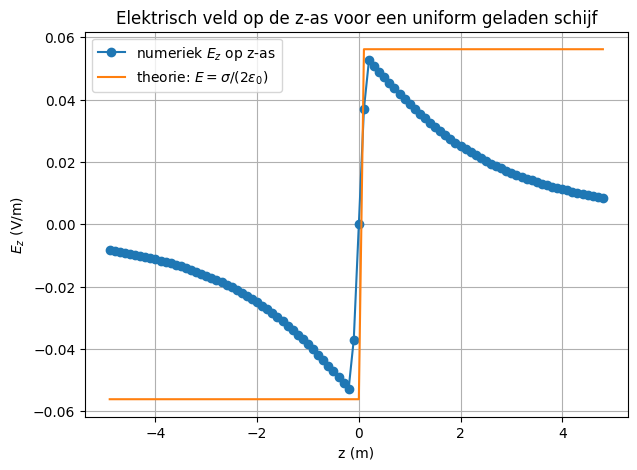

In [39]:
###
# 1. Numeriek E_z op de z-as (r = 0)

###
# 1. Numeriek E_z op de z-as (r = 0)

idx_r_zero = np.where(abs(r) < 1e-10)[0][0]   # vind de index waar r = 0 (de as)
Ez_z_numeric = Ez[:, idx_r_zero]              # selecteer Ez langs de z-as (kolom r=0)

# 2. Theoretisch elektrisch veld

E_theory = sigma / (2 * epsilon0)             # theoretisch veld van een uniforme schijf
Ez_z_theory = E_theory * np.sign(Ez_z_numeric)  # maak een constante array met dezelfde lengte

# 3. Plotten met correcte z-as
plt.figure(figsize=(7,5))
plt.plot(z_for_E, Ez_z_numeric, "o-", label="numeriek $E_z$ op z-as")
plt.plot(z_for_E, Ez_z_theory, "-", label="theorie: $E = \\sigma/(2\\epsilon_0)$")

plt.title("Elektrisch veld op de z-as voor een uniform geladen schijf")
plt.xlabel("z (m)")
plt.ylabel("$E_z$ (V/m)")
plt.legend()
plt.grid(True)
# opslaan van de figuur
#plt.savefig("Ez_z_as_straal_2.png", dpi=300)
plt.show()

###

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f


1. Het numerieke veld van de schijf benadert het veld van een oneindig vlak
wanneer je dicht bij het oppervlak zit (kleine |z|) EN wanneer de straal
van de schijf veel groter is dan de afstand tot het oppervlak.
In formulevorm:
R >> |z|
In dat regime is het veld bijna constant en ongeveer gelijk aan:
E ≈ σ / (2ε0)

2. Het theoretische veld (oneindig vlak) is constant en verandert niet met z.
Daarom is de theoretische curve een horizontale lijn.
Het numerieke veld van de schijf neemt af als |z| groter wordt.
Dit komt doordat een eindige schijf randen heeft en de veldlijnen uitwaaieren.
Een oneindig vlak heeft geen randen -> veld blijft constant.
Het numerieke veld verandert van teken bij z = 0:
boven de schijf:  E_z > 0
onder de schijf:  E_z < 0
Dit is fysisch correct: het veld wijst altijd van de schijf af.
De theorie die jij plotte geeft alleen de grootte |E| -> altijd positief.
De numerieke curve ligt onder de theoretische lijn voor grotere |z|.
Een eindige schijf produceert altijd een zwakker veld dan een oneindig vlak, behalve direct op het oppervlak.




#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

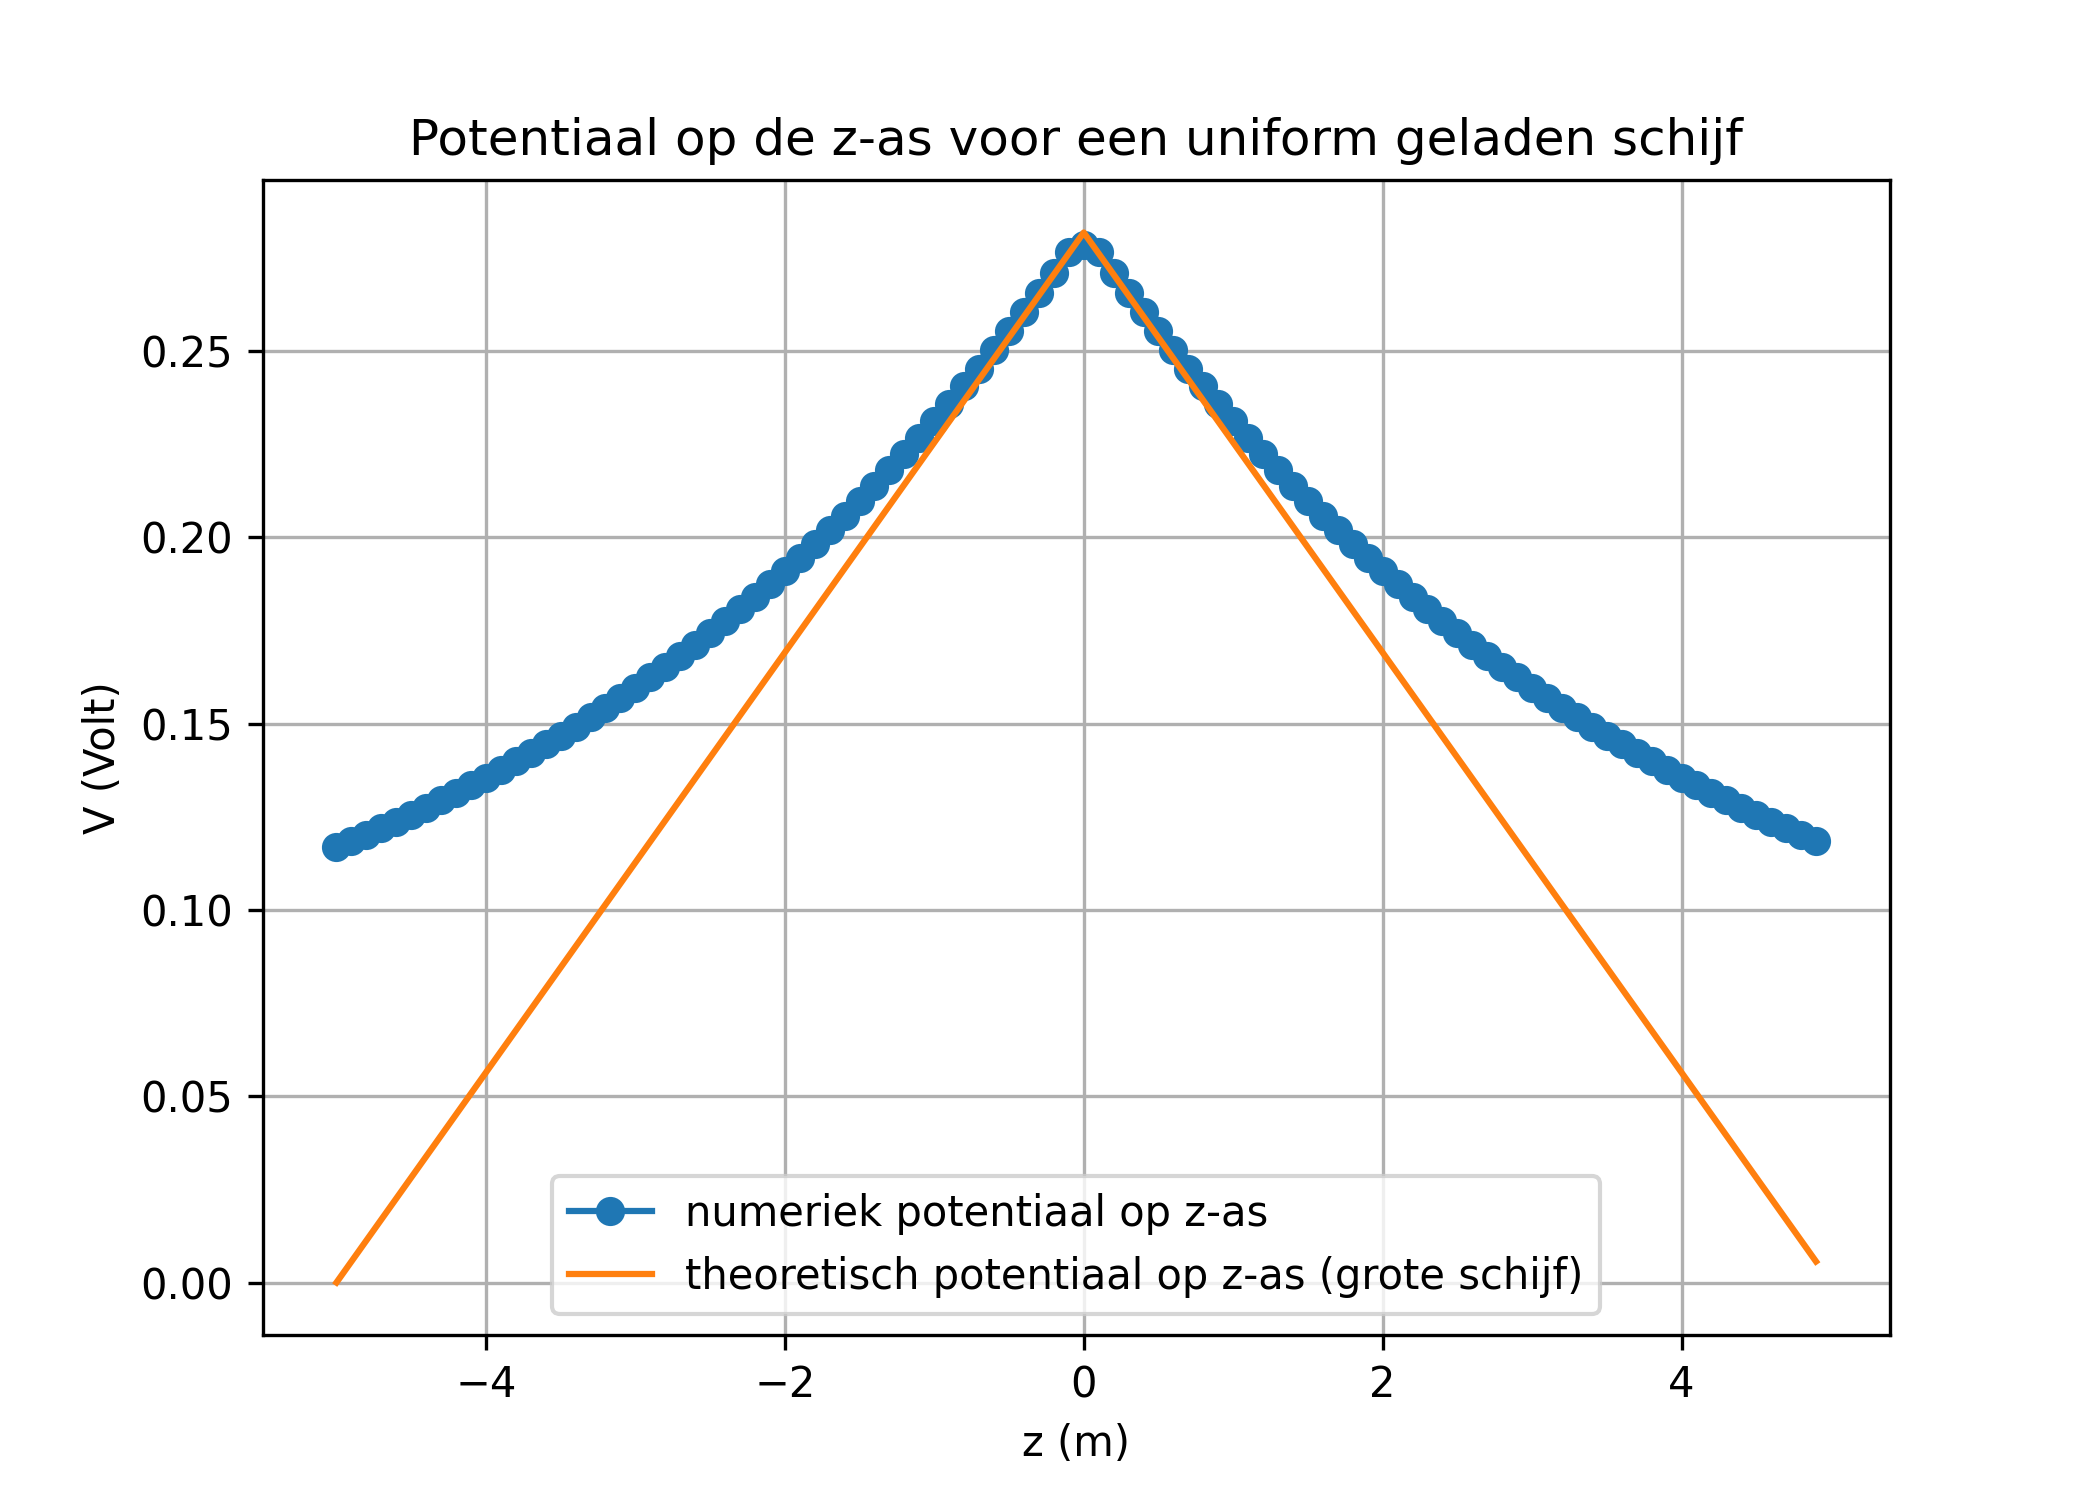

straal van de schijf hierboven is 5m 


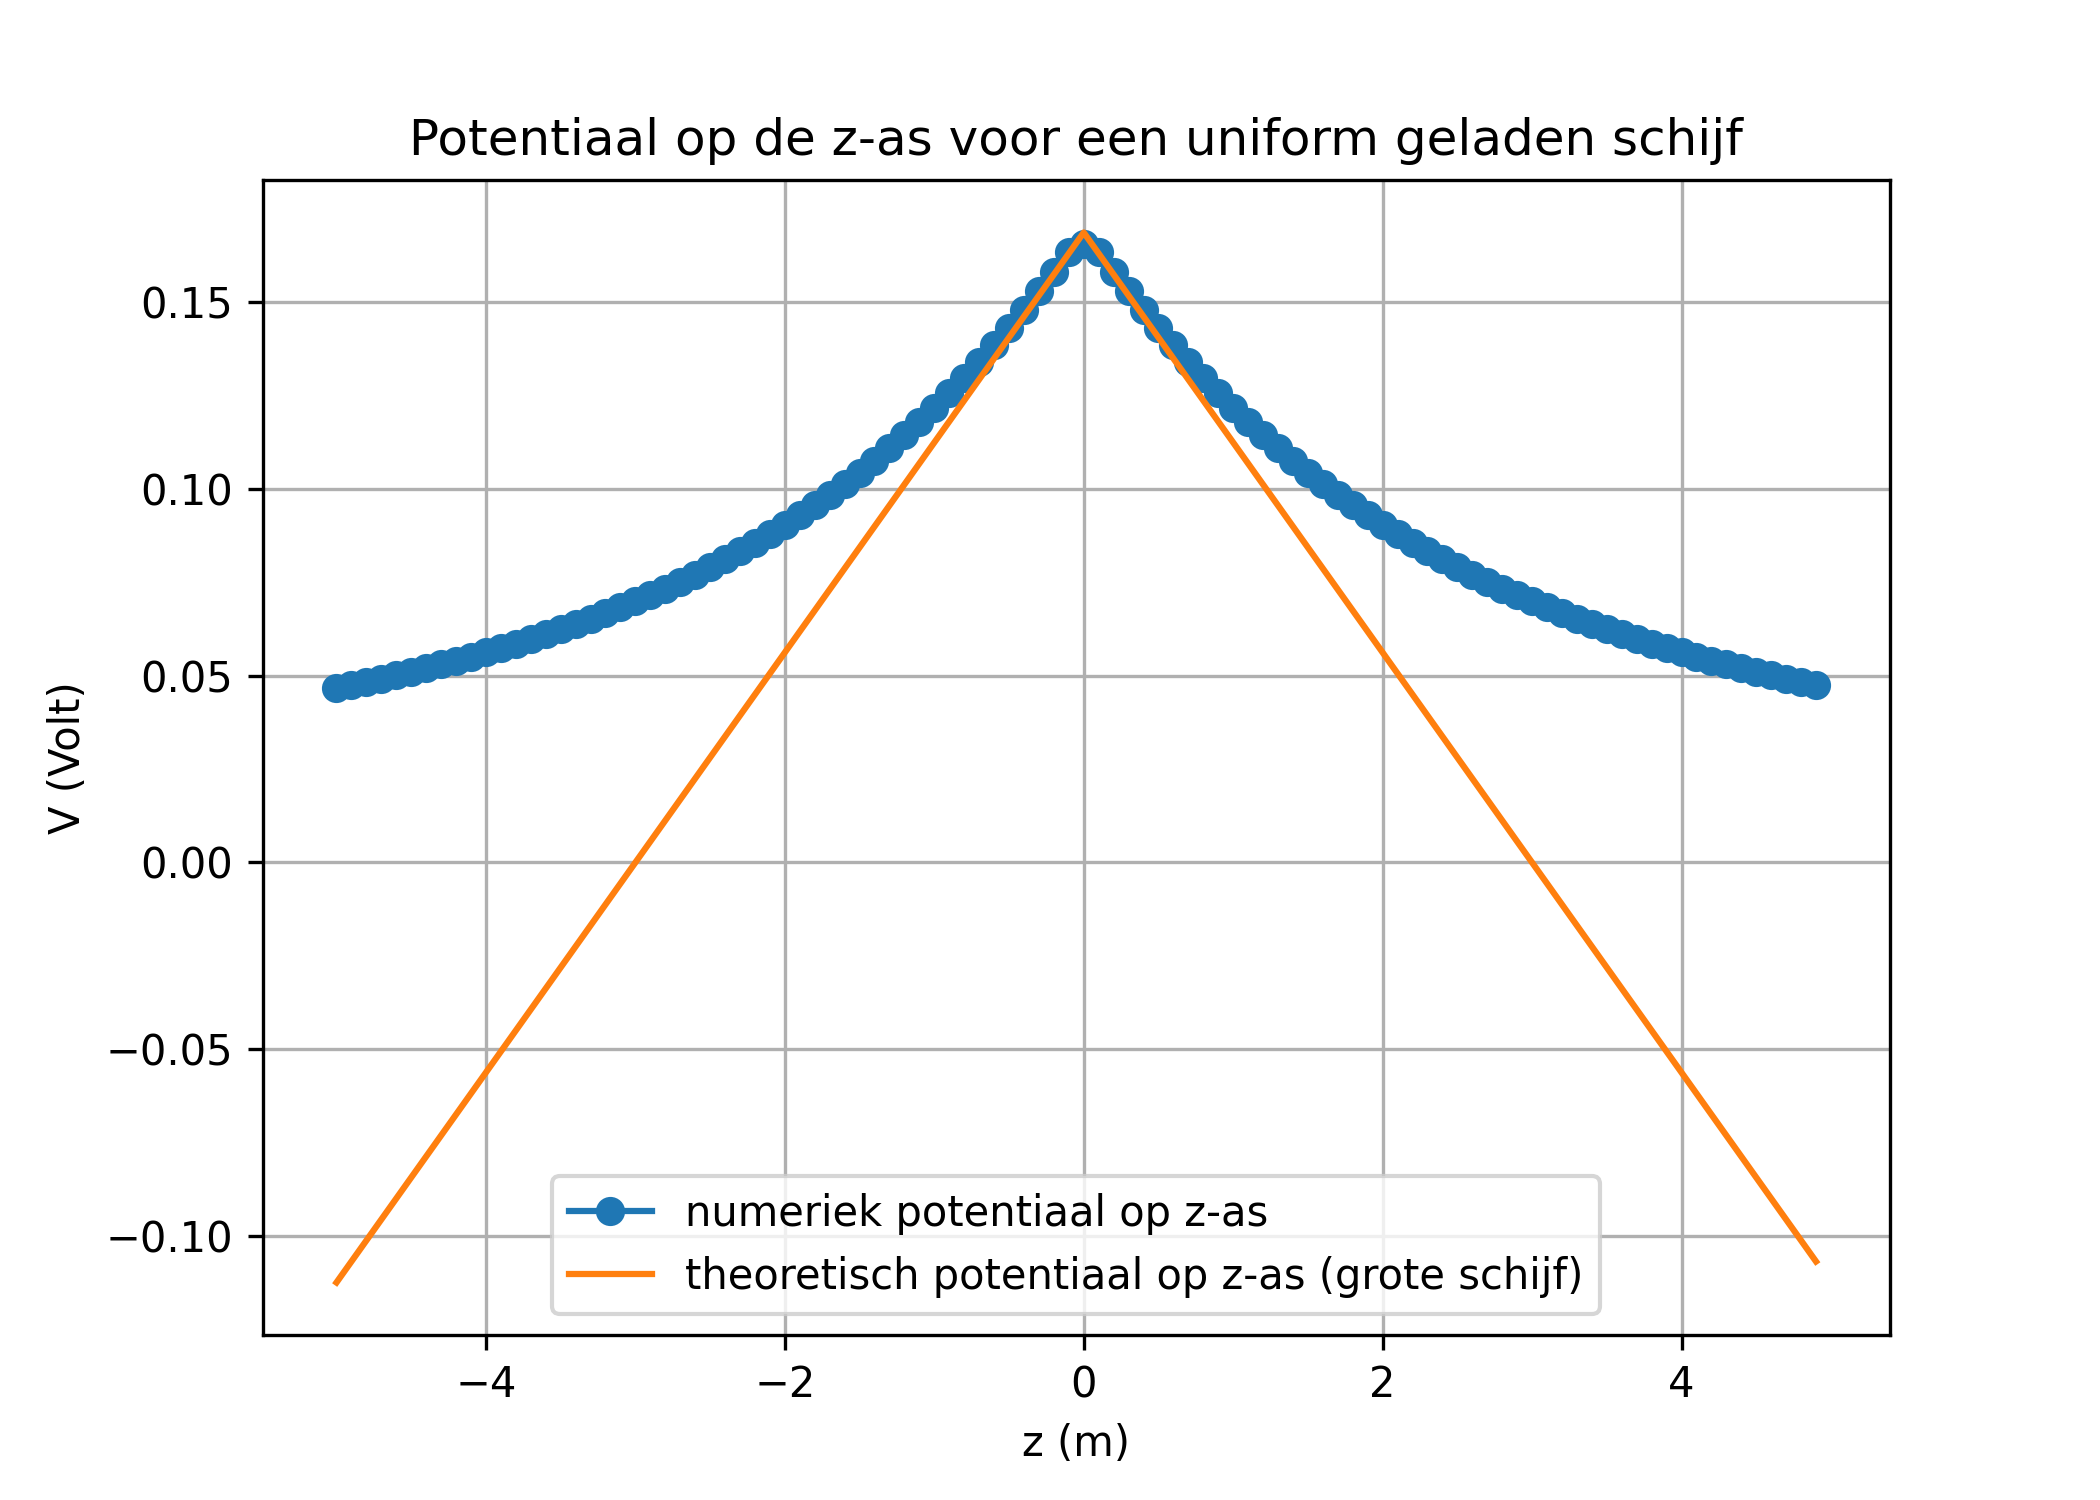

straal van de schijf hierboven is 3m


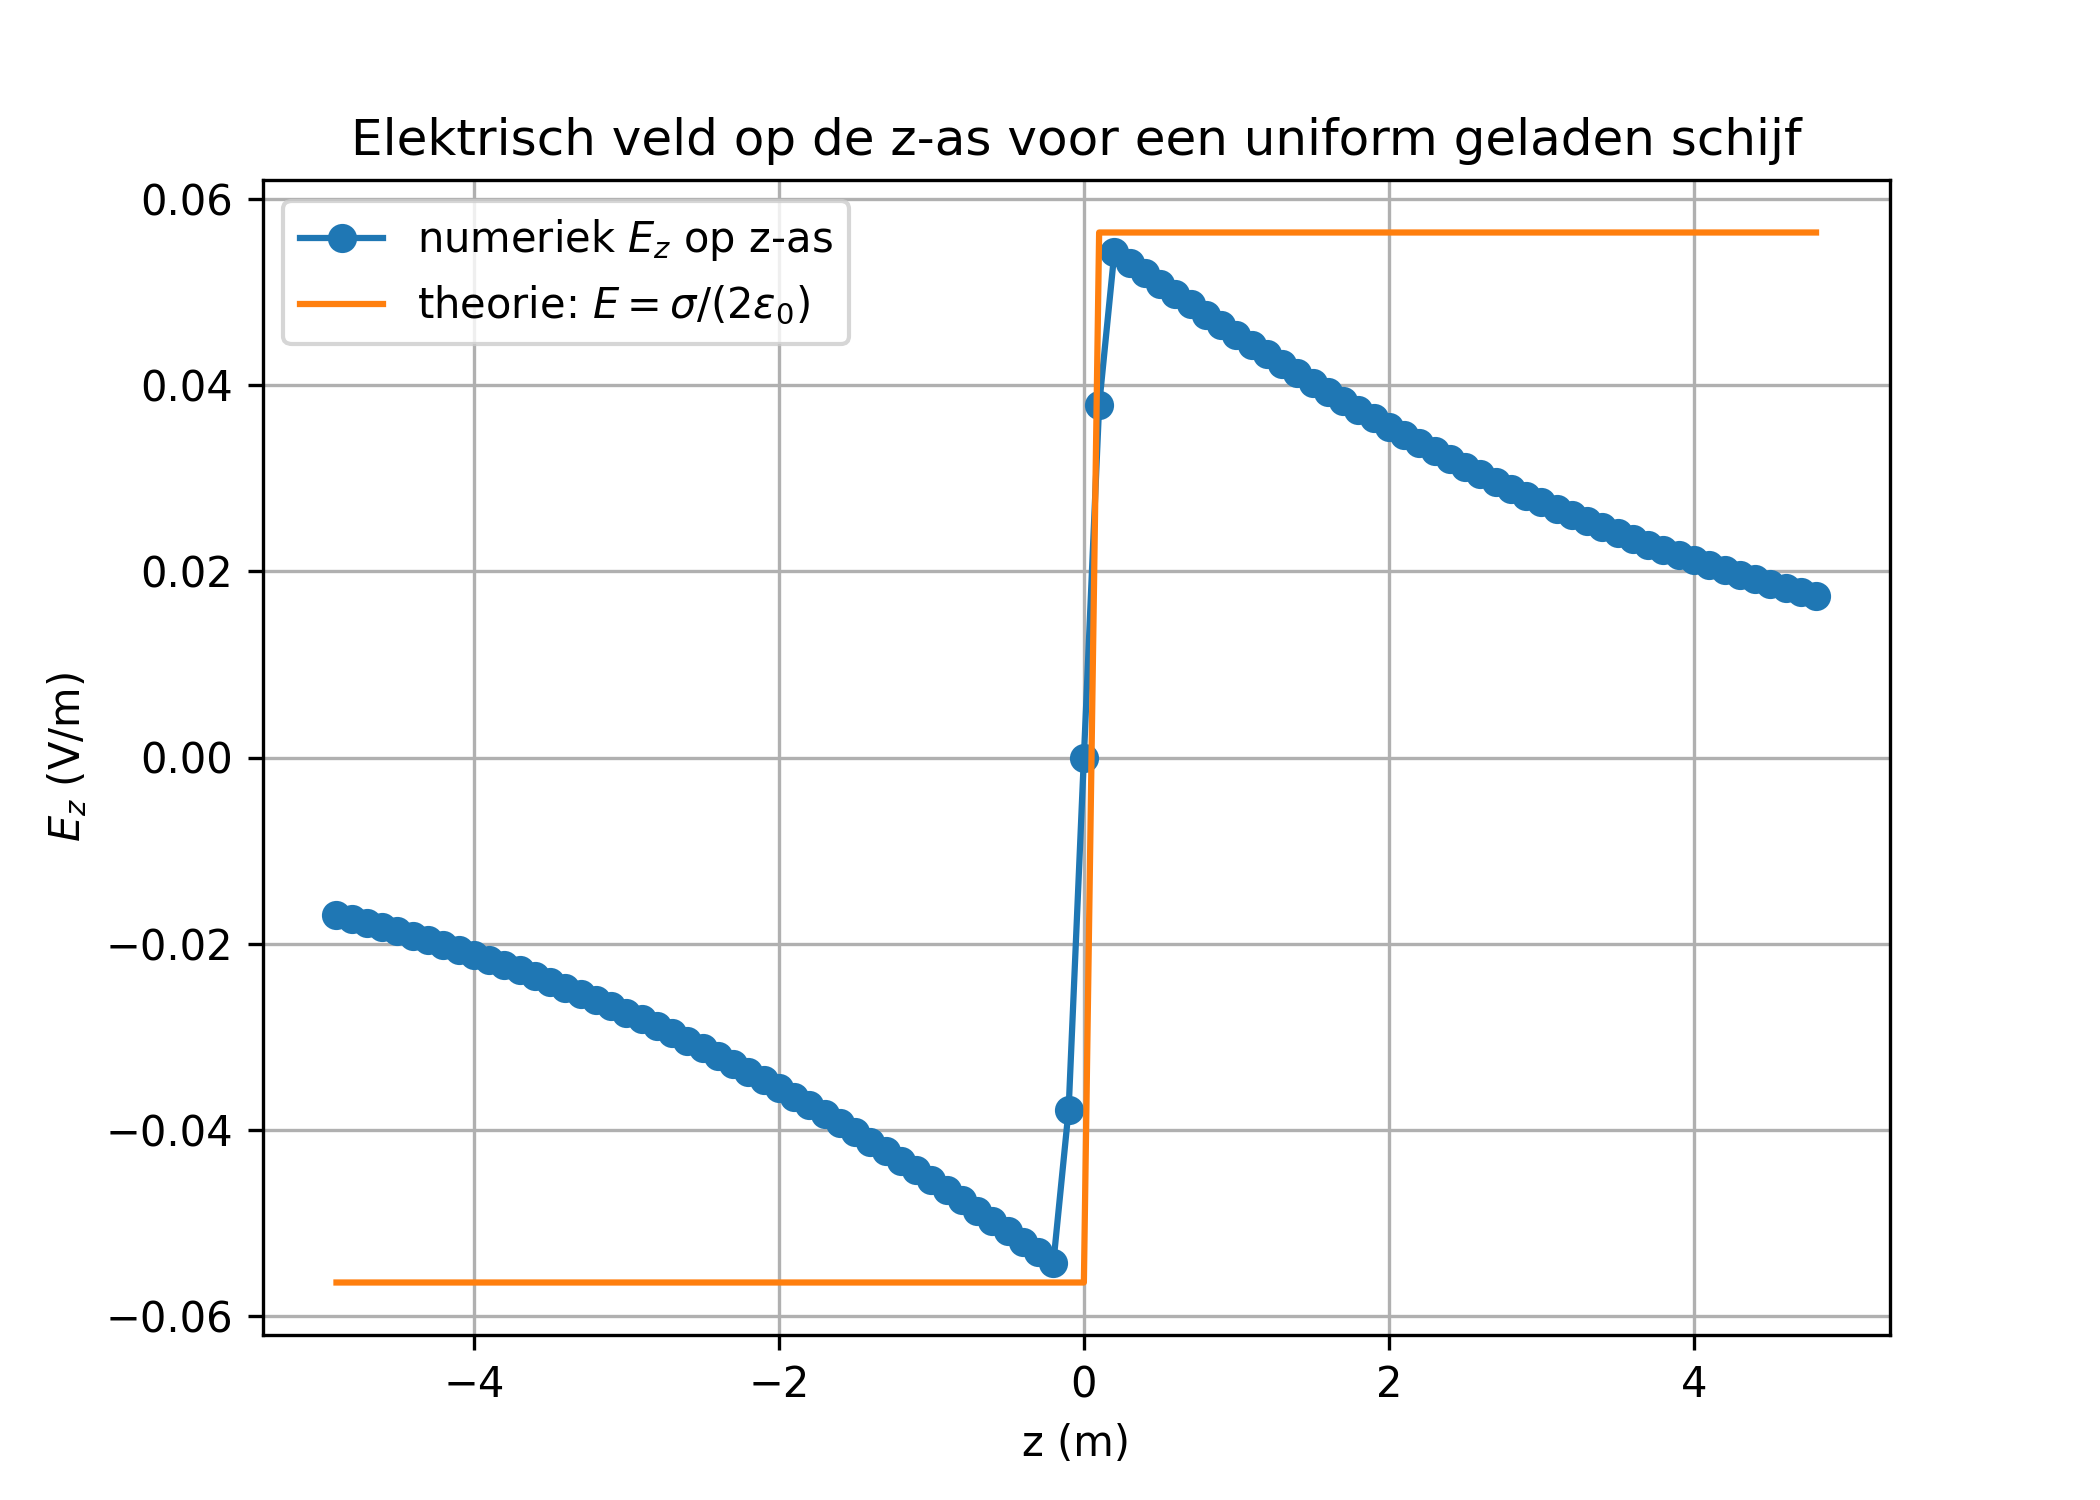

straal van de schijf hierboven is 5m 


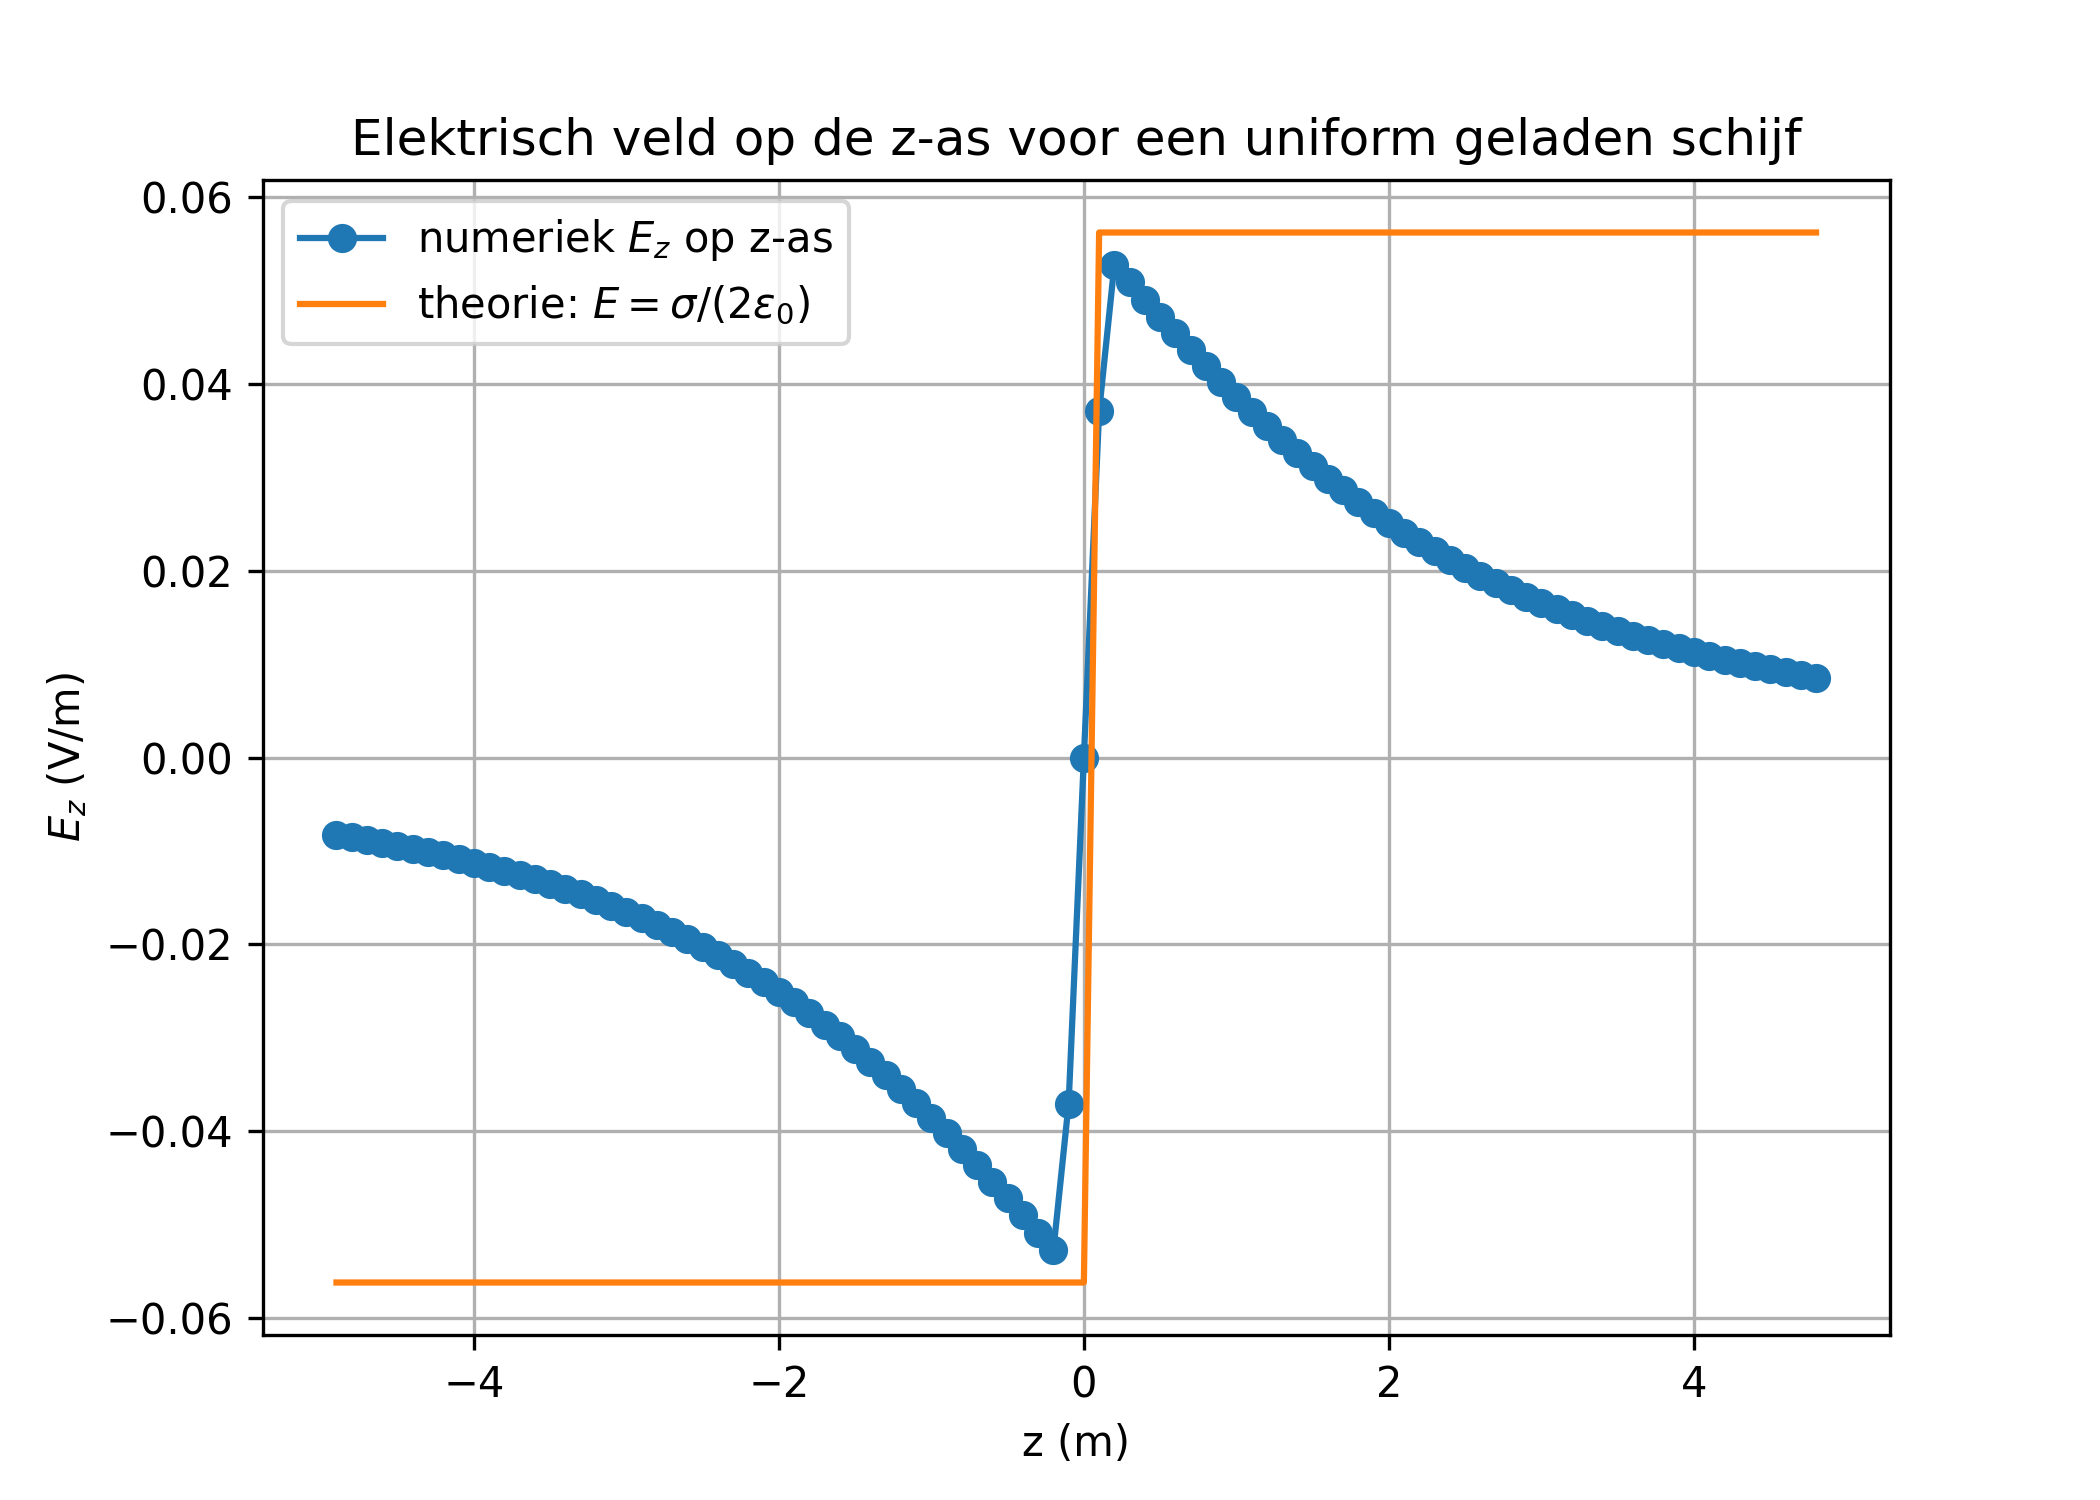

straal van de schijf hierboven is 3m


(None, None, None, None)

In [40]:
###
# Vraag 2g – Analyse van twee verschillende schijfstralen

# 1. Pas bovenaan in vraag 2 de straal van de schijf aan (bijv. disk_radius = 3 → disk_radius = 6)
#    Run daarna opnieuw vraag 2d en 2e zodat de nieuwe figuren worden opgeslagen.

# 2. Voeg hieronder de opgeslagen figuren toe:
display(Image("potentiaal_z_as_straal_2.png")), print("straal van de schijf hierboven is 5m ") , display(Image("potentiaal_z_as.png")), print("straal van de schijf hierboven is 3m") # eerst groot dan klein
display(Image("Ez_z_as_straal_2.png")),print("straal van de schijf hierboven is 5m ") , display(Image("Ez_z_as.png")), print("straal van de schijf hierboven is 3m") # eerst groot dan klein
# Zodat er geen verwarring ontstaat:
# We hebben hier de figuren van beiden stralen toegevoegd, bovendien hebben we de code weer aangepast, zodat bij de originele opdracht
# de opdracht met de normale schijf straal wordt uitgevoerd. Het opslaan van de figuren staat achter een "#", omdat anders
# de straal die er nu staat wordt opgeslagen als straal 2, maar het is straal 1. De originele straal is al een keer opgeslagen,
# dus hoeft dat niet meer. We hebben dus de code weer aangepast zodat deze overeenkomt met de originele straal, maar de figuren van beide stralen staan hier al.


#  3. Beschrijving van de verschillen tussen de twee stralen:

# - Een grotere schijfstraal zorgt ervoor dat het elektrische veld dichter bij het gedrag
#   van een oneindig geladen plaat komt. Dit zie je doordat de numerieke curve vlakker wordt
#   en dichter bij de theoretische constante waarde σ/(2ε0) ligt.

# - Bij een kleinere straal zie je dat het veld sneller afneemt wanneer |z| groter wordt.
#   Dit komt doordat de randen van de schijf een veel grotere rol spelen: veldlijnen waaieren
#   sterker uit en het veld wordt zwakker verder van de schijf.

# - De sprong in het veld bij z = 0 blijft aanwezig voor beide stralen, maar bij een grotere straal
#   is de waarde net boven en onder de schijf dichter bij de theoretische waarde van een oneindig vlak.

# - Samengevat:
#   Grote straal -> veld lijkt meer op een oneindig vlak (vlak, bijna constant).
#   Kleine straal -> veld neemt sneller af, duidelijk eindige-schijf-effecten.
###


#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

#Antwoord 2h

#Als het elektrische veld door de schijf 10% is ivm dat van een oneindige plaat.
#Oneindige plaat ->  E_inf = σ/(2ε0)

#Dus moet " 1-(z/(np.sqrt(R^2+z^2)))" 0.1 zijn
#z/(np.sqrt(R^2+z^2)) = 0.9
#z^2/(R^2+z^2) = 0.81
#z^2 = 0.81R^2 + 0.81z^2
#0.19z^2 = 0.81R^2
-volgende markdowncell staat het antwoord:


In [41]:
z = np.sqrt(0.81/0.19)
print(f"z = {z:.3f} R")
# het antwoord is dus afhankelijk van de straal van de schijf. 

z = 2.065 R


### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

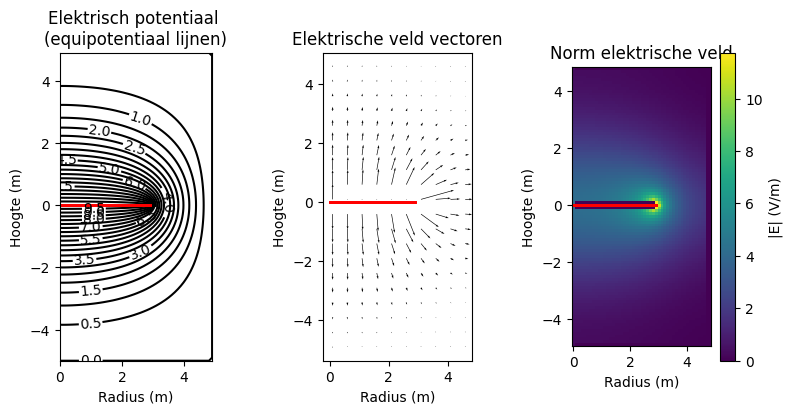

In [42]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

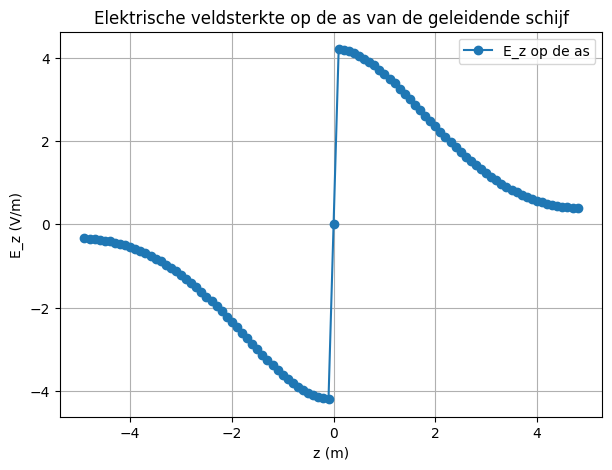

Norm van het elektrische veld dicht bij het midden van de schijf:
E = 1.521e-05 V/m


In [43]:
# De as is gewoon kolom 0 van Ez
Ez_on_axis = Ez[:, 0] # selecteer het elektrische veld Ez langs de z-as (r = 0)


# Plot van het elektrische veld op de as
plt.figure(figsize=(7,5))
plt.plot(z_for_E, Ez_on_axis, "o-", label="E_z op de as")
plt.xlabel("z (m)")
plt.ylabel("E_z (V/m)")
plt.title("Elektrische veldsterkte op de as van de geleidende schijf")
plt.grid(True)
plt.legend()
plt.show()

# Norm van het elektrische veld dicht bij het midden (z ≈ 0)
idx_z_near_center = np.argmin(np.abs(z_for_E - 0))   # vind de index van het punt dat het dichtst bij z = 0 ligt
E_center = normE[idx_z_near_center, 0]               # neem de norm van het veld op de as (r = 0) op dat z-punt

print(f"Norm van het elektrische veld dicht bij het midden van de schijf:")
print(f"E = {E_center:.3e} V/m")
###

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 1
1.  Formule voor de oppervlaktelading in het midden van de schijf:
σ = ε0 * E_n
waarbij E_n de normaalcomponent van het elektrische veld net buiten het oppervlak is.
In dit geval is dat de z-component: E_n = E_z(r=0, z = z_pos_disk1+)


In [44]:
#vraag 3b 2. Benadering van de oppervlaktelading in het midden van de schijf (r=0, z=0)
# Index op de as (r = 0)
idx_r_axis = 0                                   # r = 0 komt overeen met kolom 0 van het rooster

# Index net boven het oppervlak van de schijf (z ≈ z_pos_disk1)
idx_z_above_disk = np.argmin(np.abs(z_for_E - z_pos_disk1))   # vind het z-punt dat het dichtst bij de schijf ligt

# Normaalcomponent van het veld (z-richting) net boven de schijf
E_normal_center = Ez[idx_z_above_disk, idx_r_axis]            # neem Ez op de as, net boven de schijf

# Benadering van de oppervlaktelading in het midden
sigma_center = epsilon0 * E_normal_center                     # gebruik σ = ε0 * E om ladingsdichtheid te schatten

print("Benadering van de oppervlaktelading in het midden van de schijf (r=0, z=0):")
print(f"σ = {sigma_center:.3e} C/m^2")

Benadering van de oppervlaktelading in het midden van de schijf (r=0, z=0):
σ = 1.347e-16 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


Totale lading op de schijf: Q = 7.6176e-15 C
Oppervlaktelading in het centrum (geleidende schijf): σ(0) = 1.3471e-16 C/m²
Oppervlaktelading uniform verdeelde schijf: σ_uniform = 2.6942e-16 C/m²


C:\Users\Joppe\AppData\Local\Temp\ipykernel_30252\2707339867.py:27: RuntimeWarning: divide by zero encountered in divide
  sigma_conductor = Q / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r_vals**2))


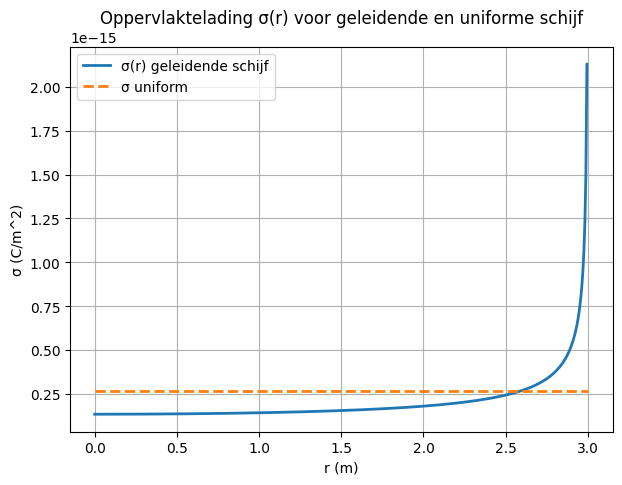

In [45]:
###
# 1. Totale lading Q bepalen

# σ(0) uit vraag 3b (oppervlaktelading in het midden)
# Voor een geleidende schijf geldt:
# σ(r) = Q / (2πR sqrt(R^2 - r^2))
# Bij r = 0:
# σ(0) = Q / (2πR^2)
# -> Q = σ(0) * 2πR^2

Q = sigma_center * 2 * np.pi * disk_radius**2      # totale lading berekend uit σ(0) voor een geleidende schijf

print(f"Totale lading op de schijf: Q = {Q:.4e} C")

# 2. Vergelijking met uniforme schijf

sigma_uniform = Q / (np.pi * disk_radius**2)       # oppervlaktelading als de schijf uniform geladen zou zijn

print(f"Oppervlaktelading in het centrum (geleidende schijf): σ(0) = {sigma_center:.4e} C/m²")
print(f"Oppervlaktelading uniform verdeelde schijf: σ_uniform = {sigma_uniform:.4e} C/m²")

# 3) Plot σ(r) voor geleidende schijf

r_vals = np.linspace(0, disk_radius, 500)          # rooster van r-waarden van centrum tot rand

# σ(r) volgens Griffiths
sigma_conductor = Q / (2 * np.pi * disk_radius * np.sqrt(disk_radius**2 - r_vals**2))  
# ladingsdichtheid voor een ideale geleidende schijf (divergeert bij de rand)

# σ_uniform is constant
sigma_uniform_vals = sigma_uniform * np.ones_like(r_vals)   # uniforme ladingsdichtheid over de hele schijf

plt.figure(figsize=(7,5))
plt.plot(r_vals, sigma_conductor, label="σ(r) geleidende schijf", linewidth=2)
plt.plot(r_vals, sigma_uniform_vals, label="σ uniform", linestyle="--", linewidth=2)

plt.xlabel("r (m)")
plt.ylabel("σ (C/m^2)")
plt.title("Oppervlaktelading σ(r) voor geleidende en uniforme schijf")
plt.grid(True)
plt.legend()
plt.show()
###

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [46]:
# Deze cel kan je gebruiken om van vraag 3c 1 tot en met 4 te beantwoorden.

# 1. Maximum van het elektrische veld (normE)
E_max = np.max(normE)                           # bepaal de grootste waarde van |E| in het hele rooster

# 2. Locatie van het maximum
idx_z_max, idx_r_max = np.unravel_index(np.argmax(normE), normE.shape)                                               # vind de (z,r)-index waar |E| maximaal is

z_max = z_for_E[idx_z_max]                      # bijbehorende z-positie van het maximum
r_max = r_for_E[idx_r_max]                      # bijbehorende r-positie van het maximum

# 3. Elektrisch veld in het midden van de schijf (r=0, z≈0)
idx_z_center = np.argmin(np.abs(z_for_E - 0))   # index van het punt dat het dichtst bij z = 0 ligt
E_center = normE[idx_z_center, 0]               # veldnorm op de as (r = 0) in het midden

ratio = E_max / E_center                        # verhouding tussen maximale veldsterkte en veld in het centrum

# 4. Netjes printen
print("Edge Effect Analyse")
print(f"Maximale elektrische veldsterkte:     E_max = {E_max:.3e} V/m")
print(f"Locatie van dit maximum:              r = {r_max:.3e} m,  z = {z_max:.3e} m")
print(f"Elektrisch veld in het midden:        E_center = {E_center:.3e} V/m")
print(f"Verhouding (E_max / E_center):        {ratio:.3e}x sterker aan de rand")



Edge Effect Analyse
Maximale elektrische veldsterkte:     E_max = 1.175e+01 V/m
Locatie van dit maximum:              r = 3.000e+00 m,  z = 1.000e-01 m
Elektrisch veld in het midden:        E_center = 1.521e-05 V/m
Verhouding (E_max / E_center):        7.725e+05x sterker aan de rand


##### Antwoord 3d.5

Het elektrische veld is lokaal veel hoger aan de rand van de geleidende schijf,
omdat ladingen zich ophopen bij scherpe randen. Dit veroorzaakt een sterke
versterking van het elektrische veld: het 'edge effect'.


### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

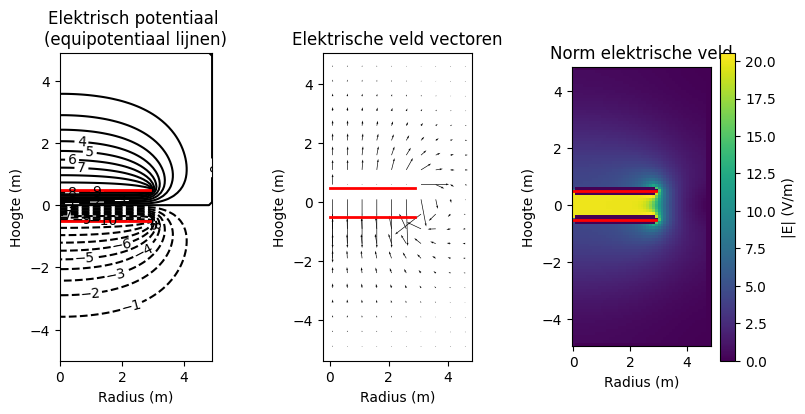

In [47]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 1  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


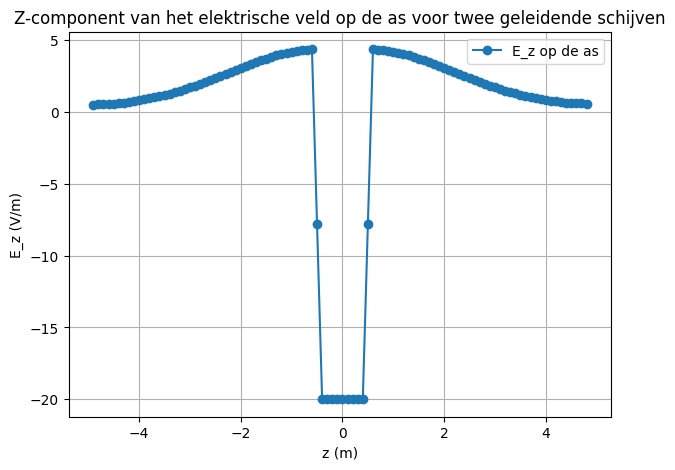

In [48]:
###
# Het z-component van het elektrische veld op de as (r = 0)
Ez_on_axis = Ez[:, 0]

plt.figure(figsize=(7,5))
plt.plot(z_for_E, Ez_on_axis, "o-", label="E_z op de as")
plt.xlabel("z (m)")
plt.ylabel("E_z (V/m)")
plt.title("Z-component van het elektrische veld op de as voor twee geleidende schijven")
plt.grid(True)
plt.legend()
plt.show()

###

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

### Antwoorden 4b
##### 1. Theoretisch elektrisch veld tussen twee geleidende platen
We beschouwen twee geleidende schijven (of platen) met potentiaalverschil  
Het potentiaal verandert lineair tussen twee platen:

$$
V(z) = V_1 - \frac{\Delta V}{d}(z - z_1)
$$

Het elektrische veld is:

$$
E_z = -\frac{dV}{dz} = \frac{\Delta V}{d}
$$

Dit veld is:

- **uniform** tussen de platen  
- **gericht van de positieve naar de negatieve plaat**  
- **nul buiten de platen**, omdat de velden elkaar daar opheffen

#### Afleiding

Het potentiaal verandert lineair tussen twee platen:

$$
V(z) = V_1 - \frac{\Delta V}{d}(z - z_1)
$$

Het elektrische veld is:

$$
E_z = -\frac{dV}{dz} = \frac{\Delta V}{d}
$$
##### Schets van de verschillende regio’s
![schets theoretisch elektrisch veld](ElektrischeVVDOO1.jpeg)



---

#### 2.
Tussen de schijven is het elektrische veld redelijk constant, buiten de schijven is het elektrische veld heel klein en gaat naar de 0 naarmate de afstand tot de schijven groter wordt. Dit komt redelijk overeen met het theoretische veld, alleen is in de theorie het elektrische veld buiten de schijven 0 en het numerieke veld is dat niet. 
#### 3. 
Bij twee schijven ontstaat er een constant veld tussen de schijven, terwijl er bij een enkele schijf geen enkel constant gebied is.




#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [49]:
###
# 1. Verwachte oppervlaktelading op de binnenzijde van één schijf
DeltaV = V1 - V2              # potentiaalverschil
d = spacing_between_disks     # afstand tussen de platen
E_theory = DeltaV / d         # uniform veld tussen platen

sigma_inner = epsilon0 * E_theory   # σ = ε0 E

# 2. Verwachte totale lading op beide schijven
A = np.pi * disk_radius**2
Q_single = sigma_inner * A         # lading op één schijf (binnenzijde)
Q_total = 2 * Q_single             # totale |lading| op beide schijven samen

# 3. Capaciteit van de configuratie
C = Q_single / DeltaV              # of: C = ε0 A / d

# 4. Netjes printen
print(f"Potentiaalverschil delta_V:                  {DeltaV:.3e} V")
print(f"Theoretisch veld tussen de platen E:    {E_theory:.3e} V/m")
print(f"Oppervlaktelading binnenzijde σ:        {sigma_inner:.3e} C/m²")
print(f"Lading op één schijf (binnenzijde) Q:   {Q_single:.3e} C")
print(f"Totale lading op beide schijven |Q|:    {Q_total:.3e} C")
print(f"Capaciteit C:                           {C:.3e} F")

###

Potentiaalverschil delta_V:                  2.000e+01 V
Theoretisch veld tussen de platen E:    2.000e+01 V/m
Oppervlaktelading binnenzijde σ:        1.771e-10 C/m²
Lading op één schijf (binnenzijde) Q:   5.007e-09 C
Totale lading op beide schijven |Q|:    1.001e-08 C
Capaciteit C:                           2.503e-10 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

### Vraag 4d: Theoretische oppervlakte‑lading

#### 1.
Nee, de lading wordt voor beide schijven naar de binnenkant getrokken, omdat de ene schijf positief en de andere schijf negatief geladen is, maar omdat de schijven niet oneindig zijn ontstaan er edge effects, waardoor er ook een kleine lading aan de buitenkant van de schijven is. 
#### 2.
$E_{\perp,buiten}-E_{\perp,binnen} = \frac{\sigma}{\epsilon_0}$

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [50]:
###
# Basis: veld op de as en roosterstap in z-richting
Ez_on_axis = Ez[:, 0]                 # selecteer Ez langs de z-as (r = 0)
dz = z_for_E[1] - z_for_E[0]          # bepaal de roosterstap in de z-richting

# 1. Ez net onder de onderste schijf (buitenzijde)
z_below = z_pos_disk2 - dz/2          # positie net onder de schijf
idx_below = np.argmin(np.abs(z_for_E - z_below))   # index van dichtstbijzijnde roosterpunt
Ez_below = Ez_on_axis[idx_below]      # veldwaarde net onder de schijf

# 2. σ aan de onderkant (buitenzijde) volgens E = σ/ε0
sigma_bottom_outer = epsilon0 * Ez_below   # ladingsdichtheid via σ = ε0 E

# 3. Ez net boven de onderste schijf (binnenzijde, tussen de platen)
z_above = z_pos_disk2 + dz/2          # positie net boven de schijf
idx_above = np.argmin(np.abs(z_for_E - z_above))   # index van dichtstbijzijnde roosterpunt
Ez_above = Ez_on_axis[idx_above]      # veldwaarde net boven de schijf

# 4. σ aan de bovenkant (binnenzijde) volgens E = σ/ε0
sigma_bottom_inner = epsilon0 * Ez_above   # ladingsdichtheid op de binnenzijde

# 5   Netjes printen
print("Vraag 4e: Numeriek berekende ladingsdichtheid")
print(f"z-positie onderste schijf:                 z = {z_pos_disk2:.3e} m\n")

print(f"1. Ez net onder de onderste schijf:        Ez_below  = {Ez_below:.3e} V/m")
print(f"2. σ onderkant (buitenzijde):              σ_outer   = {sigma_bottom_outer:.3e} C/m^2\n")

print(f"3. Ez net boven de onderste schijf:        Ez_above  = {Ez_above:.3e} V/m")
print(f"4. σ bovenkant (binnenzijde):              σ_inner   = {sigma_bottom_inner:.3e} C/m^2")

Vraag 4e: Numeriek berekende ladingsdichtheid
z-positie onderste schijf:                 z = -5.000e-01 m

1. Ez net onder de onderste schijf:        Ez_below  = -7.815e+00 V/m
2. σ onderkant (buitenzijde):              σ_outer   = -6.919e-11 C/m^2

3. Ez net boven de onderste schijf:        Ez_above  = -2.000e+01 V/m
4. σ bovenkant (binnenzijde):              σ_inner   = -1.771e-10 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

#### 1.
Deze anders zijn, omdat er in 4c uitgegaan wordt van een ideale situatie, terwijl er bij 4e een realistische situatie wordt gebruikt. 
#### 2.
Deze zal lager zijn, omdat er ook een deel van de lading naar buiten "lekt". 
#### 3.
Als de afstand kleiner wordt tussen de schijven, dan lekt er minder lading naar buiten en wordt de capaciteit groter.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [51]:

def vlakkeplaat(A, d, eps_r=1.0):
    eps0 = 8.854e-12
    eps = eps0 * eps_r
    C = eps * A / d
    return C


def cilinder(a, b, L, eps_r=1.0):
    eps0 = 8.854e-12
    eps = eps0 * eps_r
    C = 2 * np.pi * eps * L / np.log(b / a)
    return C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [52]:
###
###your code here###
###

# 1:
print("1:")
C = vlakkeplaat(0.01, 0.001, eps_r=1)

print(f"Capaciteit: {C:.3e} F")
print(f"Capaciteit: {C*1e12:.2f} pF")
print()

# 2:
print("2:")
C = cilinder(0.0045, 0.0050, 0.10, eps_r=1)

print(f"Capaciteit: {C:.3e} F")
print(f"Capaciteit: {C*1e12:.2f} pF")
print()

# 3:
print("3:")
C1 = vlakkeplaat(0.01, 0.002, eps_r=1)

print(f"Plaat (afstand verdubbeld): {C1:.3e} F")
print(f"Plaat (afstand verdubbeld): {C1*1e12:.2f} pF")
print()
C2 = cilinder(0.0045, 0.0055, 0.10, eps_r=1)

print(f"Cilinder (afstand verdubbeld): {C2:.3e} F")
print(f"Cilinder (afstandverdubbeld): {C2*1e12:.2f} pF")
print()
# 4:
print("4:")
C1 = vlakkeplaat(0.01, 0.001, eps_r=80)

print(f"Plaat (water): {C1:.3e} F")
print(f"Plaat (water): {C1*1e9:.2f} nF")
print()
C2 = cilinder(0.0045, 0.0050, 0.10, eps_r=80)

print(f"Cilinder (water): {C2:.3e} F")
print(f"Cilinder (water): {C2*1e9:.2f} nF")
print()
# 5:
print("5:")
C1 = vlakkeplaat(0.01, 0.001, eps_r=3)

print(f"Plaat (PVC): {C1:.3e} F")
print(f"Plaat (PVC): {C1*1e12:.2f} pF")
print()
C2 = cilinder(0.0045, 0.0050, 0.10, eps_r=3)

print(f"Cilinder (PVC): {C2:.3e} F")
print(f"Cilinder (PVC): {C2*1e12:.2f} pF")
print()

1:
Capaciteit: 8.854e-11 F
Capaciteit: 88.54 pF

2:
Capaciteit: 5.280e-11 F
Capaciteit: 52.80 pF

3:
Plaat (afstand verdubbeld): 4.427e-11 F
Plaat (afstand verdubbeld): 44.27 pF

Cilinder (afstand verdubbeld): 2.772e-11 F
Cilinder (afstandverdubbeld): 27.72 pF

4:
Plaat (water): 7.083e-09 F
Plaat (water): 7.08 nF

Cilinder (water): 4.224e-09 F
Cilinder (water): 4.22 nF

5:
Plaat (PVC): 2.656e-10 F
Plaat (PVC): 265.62 pF

Cilinder (PVC): 1.584e-10 F
Cilinder (PVC): 158.40 pF



#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [53]:
###
###Jouw code hier###
###
C_target = 1e-6   # 1 µF

# 1:
a = 5e-3 / 2      # inner radius (m)
b = 6e-3 / 2      # outer radius (m)

# solve formula for L:
# C = 2πepsL / ln(b/a)  →  L = C ln(b/a) / (2πeps)

eps0 = 8.854e-12
L_needed = C_target * np.log(b/a) / (2 * np.pi * eps0)

print("Cilindercondensator (1 µF):")
print(f"Lengte: {L_needed:.3e} m  ({L_needed:.2f} m)")
print()

# 2:
d = 0.5e-3        
breedte = 6e-3    

# C = eps A / d  →  A = C d / eps
A_needed = C_target * d / eps0

# A = breedte * lengte → lengte = A / breedte
lengte_needed = A_needed / breedte

print("Vlakke plaat condensator (1 µF):")
print(f"Lengte: {lengte_needed:.3e} m  ({lengte_needed:.2f} m)")


Cilindercondensator (1 µF):
Lengte: 3.277e+03 m  (3277.32 m)

Vlakke plaat condensator (1 µF):
Lengte: 9.412e+03 m  (9411.94 m)


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

De antwoorden uit vraag 5c zijn eigenlijk niet realistisch. Als je een 1 µF condensator zou maken met lucht als diëlektricum en met de simpele modellen van een cilinder of twee vlakke platen, dan kom je uit op lengtes van duizenden meters.

De reden hiervoor zie je direct terug in de formule. Voor een vlakke plaat condensator geldt

C=εA/d



Als je lucht gebruikt, is de relatieve permittiviteit ongeveer 1, dus 
ε is klein. Dan kun je alleen een grote capaciteit krijgen door het oppervlak 
A heel groot te maken of de afstand 
d extreem klein. Maar 
d kun je niet onbeperkt verkleinen, want dan krijg je elektrische doorslag. Daardoor worden de afmetingen in onze berekening heel groot.

In echte condensatoren lossen ze dit anders op. Ze gebruiken materialen met een veel hogere relatieve permittiviteit dan lucht, zoals keramiek of een oxide-laag. Daarnaast maken ze het effectieve oppervlak veel groter door de platen op te rollen of meerdere lagen op elkaar te stapelen. Bij elektrolytische condensatoren is de isolatielaag bovendien extreem dun, waardoor 
d heel klein wordt en de capaciteit sterk toeneemt.

Kort gezegd: onze berekeningen kloppen fysisch, maar ze laten juist zien waarom echte condensatoren een slimme interne constructie nodig hebben om hoge capaciteiten in een klein volume te krijgen.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [54]:

# aannames
m = 3000          # kg gok voor treintje met 6 mensen
v = 70 / 3.6      # m/s
V = 10000         # 10 kV
eps0 = 8.854e-12
eps_r = 80        # water
d = 1e-3          # 1 mm

# energie treintje
E = 0.5 * m * v**2

# benodigde C uit E = 1/2 C V^2
C = 2 * E / V**2

# oppervlak vlakke plaat (C = eps A / d)
eps = eps0 * eps_r
A = C * d / eps

print("massa:", m, "kg")
print("snelheid:", round(v,2), "m/s")
print("energie:", round(E,0), "J")
print("benodigde C:", "{:.3e}".format(C), "F")
print("oppervlak nodig:", "{:.3e}".format(A), "m^2")
print("dat is ongeveer:", round(A,1), "vierkante meter")

massa: 3000 kg
snelheid: 19.44 m/s
energie: 567130.0 J
benodigde C: 1.134e-02 F
oppervlak nodig: 1.601e+04 m^2
dat is ongeveer: 16013.4 vierkante meter


##### Antwoorden 5e

Dit is totaal niet realistisch als je het als een grote vlakke plaat met 1mm water ertussen zou maken. Het oppervlak wordt absurd groot. In het echt wordt dit opgelost door:

Veel hogere spanningen gebruiken

Ander dielektrica dan water

heel dunne lagen

veel lagen oprollen


Anders past het nooit in een achtbaaninstallatie.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

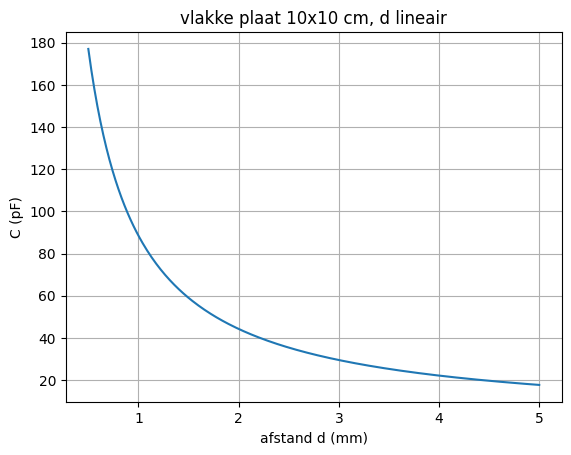

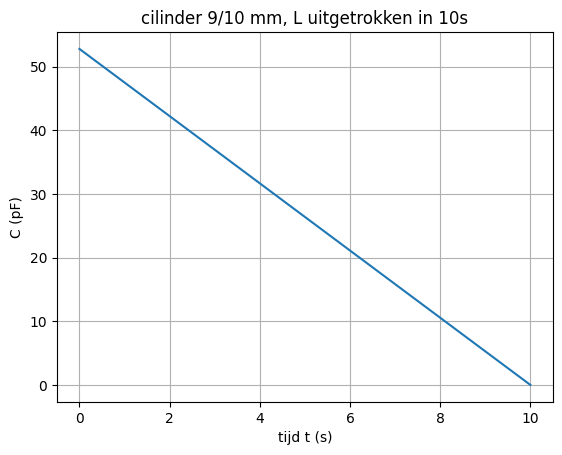

In [55]:
#!pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt

# 1) vlakke plaat, d van 0.5mm -> 5mm
A = 0.10 * 0.10
d = np.linspace(0.5e-3, 5e-3, 300)

C_plaat = np.array([vlakkeplaat(A, di, eps_r=1) for di in d])

plt.figure()
plt.plot(d*1e3, C_plaat*1e12)
plt.xlabel("afstand d (mm)")
plt.ylabel("C (pF)")
plt.title("vlakke plaat 10x10 cm, d lineair")
plt.grid(True)
plt.show()


# 2) cilinder, binnen wordt in 10s eruit getrokken, overlap L gaat naar 0
a = 9e-3 / 2
b = 10e-3 / 2
L0 = 0.10

t = np.linspace(0, 10, 300)
L = L0 * (1 - t/10)     
L[L < 0] = 0

C_cil = np.array([cilinder(a, b, Li, eps_r=1) for Li in L])

plt.figure()
plt.plot(t, C_cil*1e12)
plt.xlabel("tijd t (s)")
plt.ylabel("C (pF)")
plt.title("cilinder 9/10 mm, L uitgetrokken in 10s")
plt.grid(True)
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/Condensator_1_uF.jpg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [56]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [57]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [58]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

*Antwoord vraag 7, de laatste.*